# Heart Disease Prediction

## Objective
Build a machine learning model to predict whether a person is at risk of heart disease based on their health data.

## Dataset
Heart Disease UCI Dataset (Kaggle)

## Project Workflow
1. Data Loading
2. Data Cleaning
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. Model Building
6. Model Evaluation
7. Feature Importance Analysis
8. Conclusions

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load dataset

df = pd.read_csv("./data/heart_disease_uci.csv")

df.head() # to display first 5 rows of the dataset

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [7]:
# Dataset dimensions
print("SHAPE OF DATASET")
print("=" * 50)
print(df.shape)
print("=" * 50)

# Data types
print("\nDATA TYPES")
print("=" * 50)
print(df.info())
print("=" * 50)


# missing values
print("\nMISSING VALUES")
print("=" * 50)
print(df.isnull().sum())
print("=" * 50)


SHAPE OF DATASET
(920, 16)

DATA TYPES
<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 156.4+ KB
None

MISSING VALUES
id            0
age           0
sex           0
dataset       0
cp      

In [7]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [8]:
# here we have to check missing values, if exists 
df.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [26]:
print(df.shape) #to confirm that the data is actually loaded
print(df.head(3))

(920, 16)
  id  age   sex    dataset              cp  trestbps   chol  fbs  restecg  \
0  1   63  Male  Cleveland  typical angina     145.0  233.0  1.0      NaN   
1  2   67  Male  Cleveland    asymptomatic     160.0  286.0  0.0      NaN   
2  3   67  Male  Cleveland    asymptomatic     120.0  229.0  0.0      NaN   

   thalch  exang  oldpeak  slope   ca  thal  num  
0   150.0    0.0      2.3    NaN  0.0   NaN    0  
1   108.0    1.0      1.5    NaN  3.0   NaN    2  
2   129.0    1.0      2.6    NaN  2.0   NaN    1  


In [8]:
"""
this dataset is known to have some hidden forms of missing values, such as 'NA', 'N/A', '?', etc.
To ensure we catch all missing values, we will:

1. Convert all data to string type to normalize hidden NaN forms.
2. Strip and replace all missing representations with NaN.
3. Convert numeric columns back to their appropriate types.
4. Fill numeric columns with median (or mode if median is NaN).
5. Fill object columns with mode.
"""

# Convert to string to normalize all hidden NaN forms
df = df.astype(str)

# Strip and replace all missing representations
missing_forms = [
    'nan', 'NaN', 'NAN', 'none', 'None', 'NONE',
    'null', 'NULL', '?', '-', '', ' ',
    '<NA>', 'NA', 'N/A', 'n/a', 'na', '#N/A'
]
for col in df.columns:
    df[col] = df[col].str.strip().replace(missing_forms, np.nan)

# Convert numeric columns
cols_to_convert = ['age', 'trestbps', 'chol', 'fbs', 'restecg',
                   'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']
for col in cols_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Fill numeric columns with median
for col in df.select_dtypes(include=[np.number]).columns:
    if df[col].isnull().any():
        median_val = df[col].median()
        fill_val = median_val if not pd.isna(median_val) else (df[col].mode()[0] if not df[col].mode().empty else 0)
        df[col] = df[col].fillna(fill_val)  # ← reassignment, not inplace

# Fill object columns
for col in df.select_dtypes(include='object').columns:
    if df[col].isnull().any():
        mode_vals = df[col].mode()
        if not mode_vals.empty:
            df[col] = df[col].fillna(mode_vals[0])  # ← reassignment, not inplace

# to verify that all the missing values are handled 
print("Missing values after final cleaning:")
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())
print("\nSample of restecg, slope, thal:")
print(df[['restecg', 'slope', 'thal']].head(10))

Missing values after final cleaning:
id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

Total missing values: 0

Sample of restecg, slope, thal:
   restecg  slope  thal
0      0.0    0.0   0.0
1      0.0    0.0   0.0
2      0.0    0.0   0.0
3      0.0    0.0   0.0
4      0.0    0.0   0.0
5      0.0    0.0   0.0
6      0.0    0.0   0.0
7      0.0    0.0   0.0
8      0.0    0.0   0.0
9      0.0    0.0   0.0


In [9]:
"""
Duplicate records can bias the model and should be removed.
"""

# Checking duplicate records
print("Duplicates:", df.duplicated().sum())



Duplicates: 0


In [31]:
# there is no duplicates, if there were duplicates, we would remove them using
# df.drop_duplicates(inplace=True)
# print("New Shape:", df.shape) and can confirm that duplicates are removed.

Available Columns:
['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Target column already exists.

Final Columns:
['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


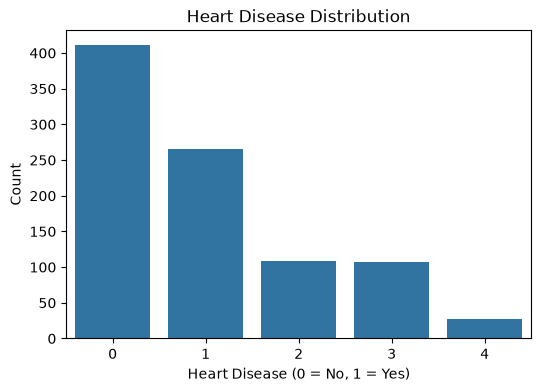

In [11]:
"""
Exploratory Data Analysis (EDA) - Visualizations
"""

# Target Variable Distribution

# Remove leading/trailing spaces from column names
df.columns = df.columns.str.strip()

print("Available Columns:")
print(df.columns.tolist())

# Common target column names in Heart Disease datasets
possible_targets = [
    'target',
    'condition',
    'output',
    'num',
    'heart_disease',
    'diagnosis'
]

# Find existing target column
target_col = None

for col in possible_targets:
    if col in df.columns:
        target_col = col
        break

# Rename to standard name 'target'
if target_col and target_col != 'target':
    df.rename(columns={target_col: 'target'}, inplace=True)
    print(f"\n'{target_col}' renamed to 'target'")
elif target_col == 'target':
    print("\nTarget column already exists.")
else:
    raise ValueError(
        f"No target column found.\nAvailable columns: {df.columns.tolist()}"
    )

# Verify
print("\nFinal Columns:")
print(df.columns.tolist())

# Display target distribution
plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df)
plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")   
plt.ylabel("Count")
plt.savefig("./images/heart_disease_distribution.png")
plt.show()


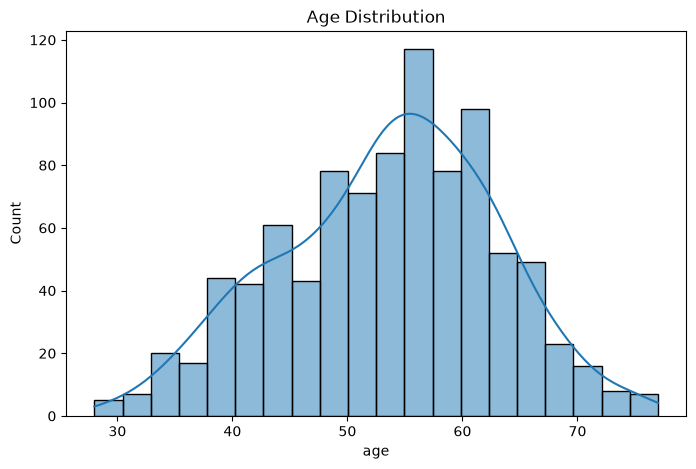

In [12]:
# age distrubution 
plt.figure(figsize=(8,5))

sns.histplot(df['age'], bins=20, kde=True)

plt.title("Age Distribution")
plt.savefig('./images/heart_disease_distribution.png', dpi=150)
plt.show()

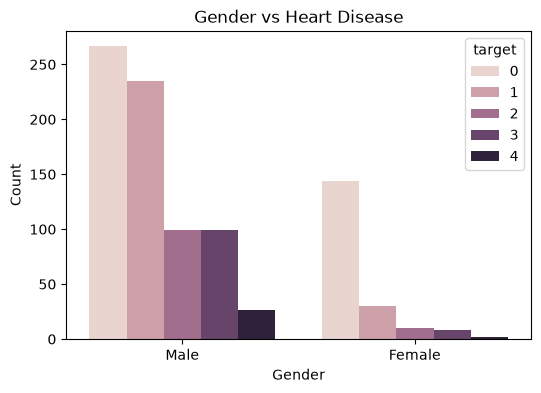

In [13]:
# Gender vs Heart Disease
plt.figure(figsize=(6,4))

# target shows the distribution of heart disease across genders 
sns.countplot(x='sex', hue='target', data=df)

plt.title("Gender vs Heart Disease")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.savefig('./images/gender_vs_heart_disease.png', dpi=150)
plt.show() 

# dimming the color means this gender has less heart disease cases, 
# while brighter color means more cases.

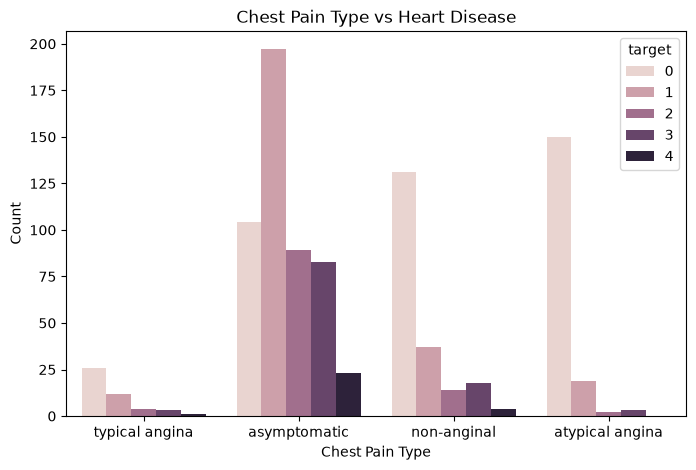

In [15]:
# Chest Pain Type Analysis

plt.figure(figsize=(8,5))

sns.countplot(x='cp', hue='target', data=df)

plt.title("Chest Pain Type vs Heart Disease")
plt.xlabel("Chest Pain Type")
plt.ylabel("Count")
plt.savefig('./images/chest_pain_vs_heart_disease.png', dpi=150)
plt.show()

# this graphs shows that certain chest pain types are more associated 
# with heart disease than others, which can be crucial for diagnosis and risk assessment.

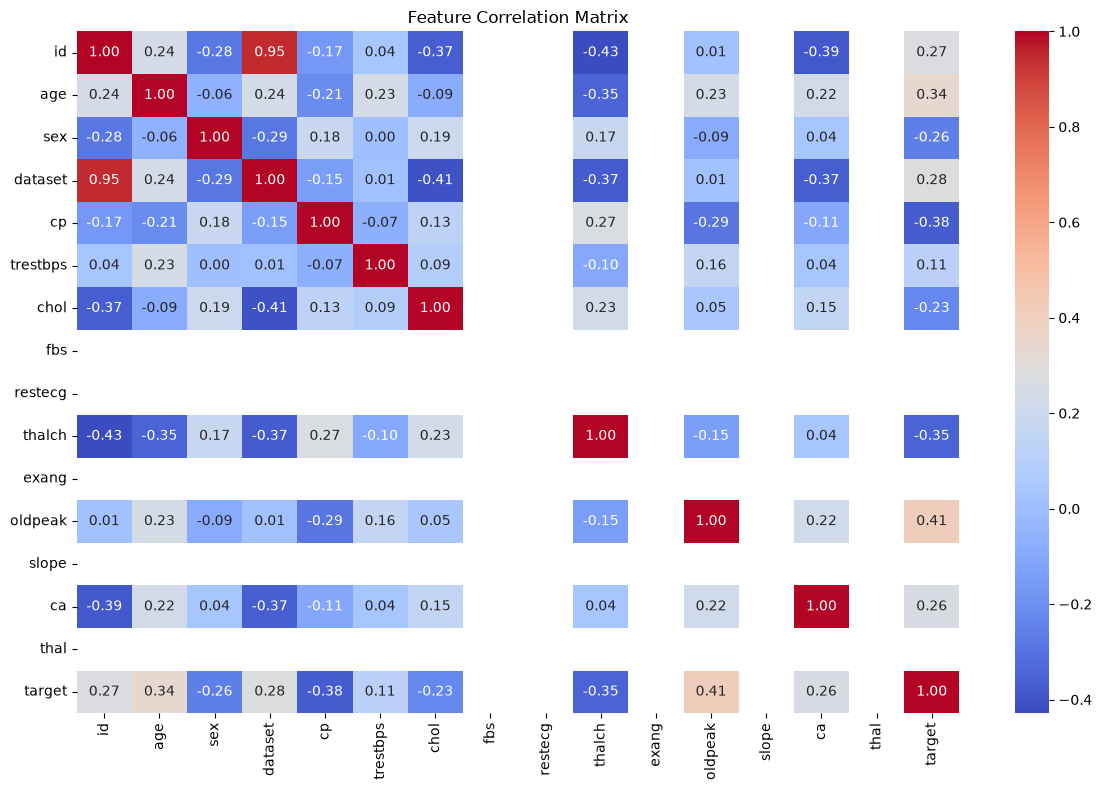

In [16]:
# Correlation Heatmap

""" 
correlation heatmap to see how features are correlated 
with each other and with the target variable
"""

df_corr = df.copy()

# Encode string columns to numeric
for col in df_corr.select_dtypes(include='object').columns:
    df_corr[col] = pd.factorize(df_corr[col])[0]

plt.figure(figsize=(12, 8))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig('./images/correlation_heatmap.png', dpi=150)
plt.show()

# correlation heatmap can help us identify which features are strongly correlated with the target variable,
# which can guide feature selection and engineering for our predictive models.

In [17]:
# Feature and Target Separation
X = df.drop('target', axis=1)
y = df['target']

# Encode string columns to numeric for modeling
for col in X.select_dtypes(include='object').columns:
    X[col] = pd.factorize(X[col])[0]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y # to maintain class distribution in train and test sets
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
# Model Training and Evaluation (Logistic Regression)
""" 
Logistic Regression is a common baseline model for binary 
classification tasks like heart disease prediction.
"""

# Create model
lr_model = LogisticRegression()

# Train model
lr_model.fit(X_train_scaled, y_train)

# Predict: whether disease is present (0 or 1)
y_pred = lr_model.predict(X_test_scaled)
y_prob = lr_model.predict_proba(X_test_scaled)[:,1] # get probabilities for ROC curve

# Accuracy Evaluation 
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy,3))


Accuracy: 0.609


In [67]:
# Classification Report 
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.84      0.84        82
           1       0.49      0.64      0.55        53
           2       0.14      0.05      0.07        22
           3       0.04      0.05      0.04        21
           4       0.00      0.00      0.00         6

    accuracy                           0.57       184
   macro avg       0.30      0.32      0.30       184
weighted avg       0.53      0.57      0.55       184



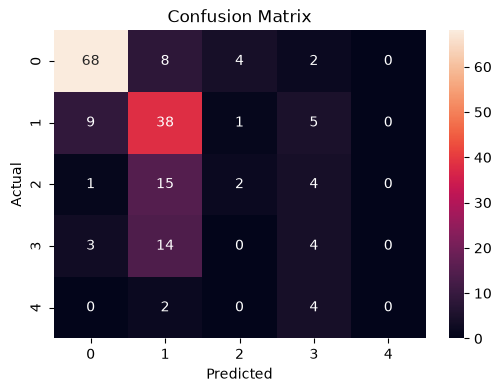

In [19]:
# Confusion Matrix
"""
 it shows:
    True Positives
    True Negatives
    False Positives
    False Negatives
    
    Very important in medical diagnosis.
 """
 
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("./images/confusion_matrix.png", dpi=150)
plt.show()

In [23]:
# ROC Curve and AUC Score 

"""
ROC Curve evaluates model performance across different classification thresholds.

AUC Score:

0.5 = Random
1.0 = Perfect

Higher is better.
"""

# Check if target contains more than 2 classes
if len(set(y_test)) > 2:
    print("Multiclass target detected. Converting to binary...")
    
    # 0 = No Heart Disease
    # Any value > 0 = Heart Disease
    y_test_binary = [0 if x == 0 else 1 for x in y_test]
    
    # If model probabilities have multiple columns,
    # use probability of having any disease
    if len(y_prob.shape) > 1:
        y_prob_binary = 1 - y_prob[:, 0]
    else:
        y_prob_binary = y_prob

    fpr, tpr, thresholds = roc_curve(y_test_binary, y_prob_binary)
    auc_score = roc_auc_score(y_test_binary, y_prob_binary)

else:
    print("Binary target detected.")
    
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)

print(f"AUC Score: {auc_score:.3f}")


Multiclass target detected. Converting to binary...
AUC Score: 0.847


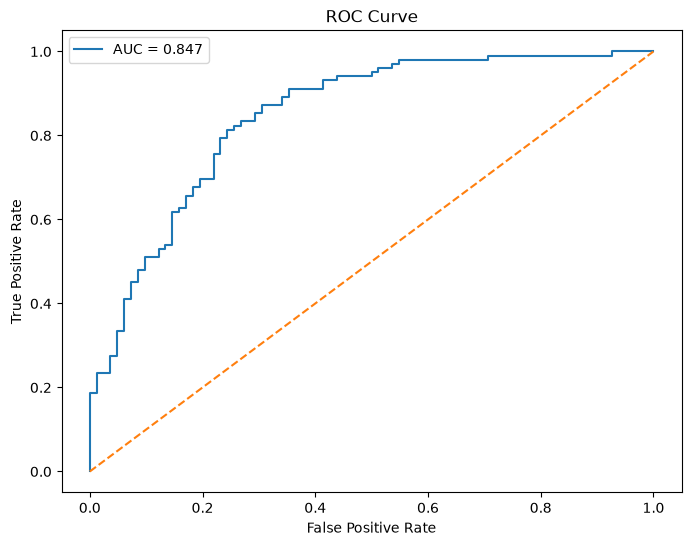

In [24]:
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()
plt.savefig("./images/roc_curve.png", dpi=150)
plt.show()

In [25]:
# Feature Importance Analysis
""" 
The coefficients indicate how strongly each feature influences prediction.

- Positive values increase the heart disease rick while
- Negative values decrease the risk.
"""

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_[0]
})

feature_importance.sort_values(
    by='Coefficient',
    ascending=False,
    inplace=True
)

feature_importance


,Feature,Coefficient
4,cp,0.533647
3,dataset,0.475386
2,sex,0.472054
6,chol,0.467325
9,thalch,0.340302
7,fbs,0.000000
8,restecg,0.000000
12,slope,0.000000
14,thal,0.000000
10,exang,0.000000


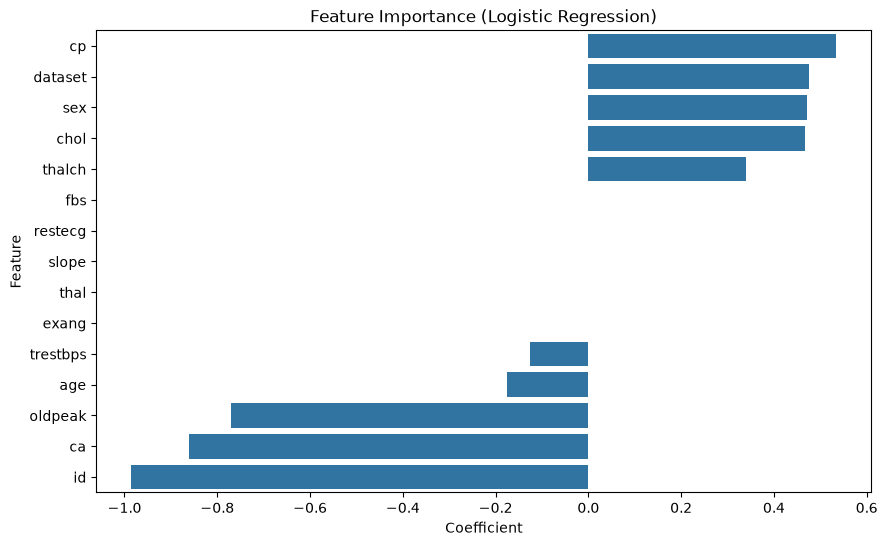

In [26]:
# here is the visualization from the above feature importance analysis
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x='Coefficient',
    y='Feature'
)

plt.title("Feature Importance (Logistic Regression)")
plt.savefig("./images/feature_importance.png", dpi=150)
plt.show()

In [27]:
"""
Here is an optional comparison of this LogisticRegression with the decision tree classifier, 
which is another common model for classification tasks.
"""

# Decision Tree Classifier
dt_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_accuracy = accuracy_score(
    y_test,
    dt_pred
)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.625


In [30]:
# Decision Tree Feature Importance

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
})

importance_df.sort_values(
    by='Importance',
    ascending=False,
    inplace=True
)

importance_df

,Feature,Importance
0,id,0.658424
13,ca,0.184253
11,oldpeak,0.055404
9,thalch,0.050499
4,cp,0.025896
2,sex,0.025524
1,age,0.000000
6,chol,0.000000
5,trestbps,0.000000
3,dataset,0.000000


In [29]:
import joblib # use for saving models

joblib.dump(
    lr_model,
    "./outputs/models/heart_disease_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


# Conclusion

## Objective Achieved
Successfully built a machine learning model to predict heart disease risk using patient health data.

## Work Completed
- Cleaned the dataset
- Handled missing values
- Performed Exploratory Data Analysis (EDA)
- Trained Logistic Regression and Decision Tree models
- Evaluated model using:
  - Accuracy
  - Confusion Matrix
  - ROC Curve
  - ROC-AUC Score
- Identified important features influencing prediction

## Key Findings
- Age, chest pain type, maximum heart rate, and ST depression were among the strongest predictors.
- Logistic Regression provided interpretable results suitable for medical applications.
- ROC-AUC score indicated good discrimination between high-risk and low-risk patients.

## Future Improvements
- Hyperparameter tuning
- Cross-validation
- Ensemble models (Random Forest, XGBoost)
- Deployment using Flask or Streamlit

# Heart Disease Prediction

## Objective
Build a machine learning model to predict whether a person is at risk of heart disease based on their health data.

## Dataset
Heart Disease UCI Dataset (Kaggle)

## Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn
- Jupyter Notebook

## Workflow
1. Data Cleaning
2. Exploratory Data Analysis
3. Feature Engineering
4. Logistic Regression
5. Decision Tree
6. Model Evaluation
7. Feature Importance Analysis

## Evaluation Metrics
- Accuracy
- Confusion Matrix
- ROC Curve
- ROC-AUC Score